In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


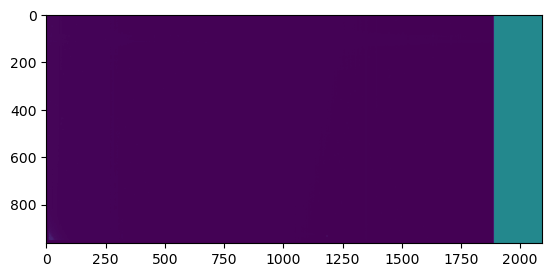

In [10]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data
plt.imshow(image_error)

In [12]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
x_axes = np.arange(0, 100, 1)
#J, N = image_cut.data.shape
##x = np.arange(0, N, 1)
#y = np.arange(0, J, 1)
#arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

#x_grid, y_grid = np.meshgrid(wavelenghts, y)
#plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
#plt.xlabel('wavelenght')

Text(0.5, 1.0, 'H$\\alpha$')

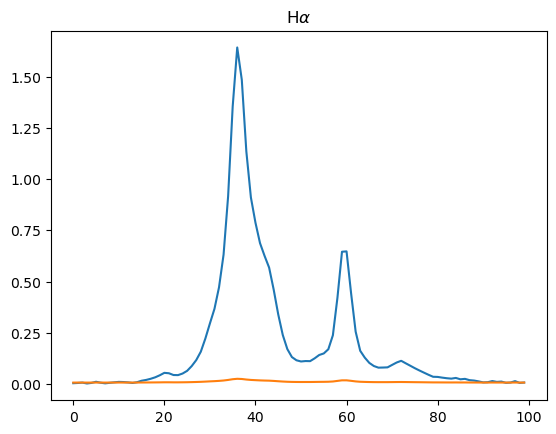

In [13]:
mask_HA = (wavelenghts > 6714)*(wavelenghts < 6724)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.mean(image_HA, axis = 1)
radial_profile_error_HA = np.mean(image_error_HA, axis = 1)
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [14]:
radial_profile_HA/radial_profile_error_HA

array([ 0.5728426 ,  0.7333071 ,  0.9668349 ,  0.39925516,  0.7754493 ,
        1.511746  ,  0.8955596 ,  0.48966634,  0.8280152 ,  1.1485479 ,
        1.4293838 ,  1.3372644 ,  1.1188408 ,  0.74222076,  1.2286464 ,
        2.136096  ,  2.608226  ,  3.2686174 ,  4.078912  ,  5.151834  ,
        6.2876287 ,  6.0671735 ,  5.2247643 ,  5.1678343 ,  5.926521  ,
        7.1742406 ,  9.209635  , 11.506493  , 14.451773  , 18.518457  ,
       22.452173  , 25.816479  , 30.348553  , 36.353054  , 45.46399   ,
       57.28248   , 63.842377  , 60.011982  , 51.30891   , 45.123333  ,
       41.449482  , 38.418777  , 36.508205  , 34.269543  , 30.074389  ,
       24.703934  , 19.426369  , 15.220439  , 12.497043  , 11.338566  ,
       10.933629  , 11.076355  , 11.036053  , 12.080521  , 13.211378  ,
       13.665115  , 14.962048  , 18.913095  , 27.315445  , 35.456585  ,
       35.53924   , 28.069668  , 19.710114  , 14.455828  , 12.293564  ,
       10.423862  ,  9.230553  ,  8.552063  ,  8.574479  ,  8.67

In [15]:
np.min(radial_profile_HA/radial_profile_error_HA)

0.39925516

In [16]:
np.max(radial_profile_HA/radial_profile_error_HA)

63.842377